# Lab Assignment 2: Data Cleaning & Clinical Data Enrichment (AI in Healthcare)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achalzz/ai-healthcare-cset343/blob/main/Lab_Assignment_2_AI_in_Healthcare.ipynb)

**Course:** B.Tech Specialization Elective (4th Year, Sem VII)  
**Course Code:** CSET343 - AI in Healthcare  
**Assignment:** Lab Assignment 2 - Data Cleaning, Missing Value Imputation, Outlier Removal, Inconsistency Correction, Feature Engineering & Feature Normalization on Clinical Data  

---

### Objective & Scope:
Clinical datasets often suffer from **missing entries**, **measurement outliers**, **implausible/inconsistent physiological values**, and **unscaled numerical features**.

This notebook provides an end-to-end Python workflow completing all **14 required tasks** on the **UCI Heart Failure Clinical Records Dataset**:
1. **Dataset Acquisition** & Direct Loading.
2. **DataFrame Inspection** & First 5 Rows Display.
3. **Dataset Summarization** (Rows, Columns, Data Types, Missing Value Counts).
4. **Missing Value Visualization** (Seaborn Heatmap).
5. **Numerical Distribution Plotting** (Histograms & Boxplots).
6. **Missing Value Imputation** (Numerical Mean/Median & Categorical Mode/Unknown).
7. **Outlier Detection & Removal** (Interquartile Range - IQR & Z-score Clipping).
8. **Clinical Inconsistency Correction** (Auditing & Rectifying Invalid Physiological Bounds).
9. **Feature Engineering** (binned `age_group` & cardiac `risk_score`).
10. **Categorical Encoding** (One-Hot / Label Encoding).
11. **Feature Normalization** (`MinMaxScaler` scaling to $[0, 1]$).
12. **Before-and-After Summary Statistics** (Mean, Median, Std Dev comparison).
13. **Cleaning Validation Plots** (Post-cleaning distribution comparison).
14. **Final Missing Value Verification** (Confirmation of clean dataset).



In [1]:
# Setup Dependencies & GPU Allocation
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print(f"[INFO] Python Version: {sys.version}")
print(f"[INFO] Pandas Version: {pd.__version__}")
print(f"[INFO] NumPy Version: {np.__version__}")



[INFO] Python Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
[INFO] Pandas Version: 3.0.2
[INFO] NumPy Version: 2.3.5


---
# Task 1 & 2: Dataset Acquisition & Loading

**Dataset:** UCI Heart Failure Clinical Records Dataset  
**Source URL:** `https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv`



In [2]:
# 1 & 2. Download and Load Dataset as pandas DataFrame
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
try:
    df_raw = pd.read_csv(dataset_url)
    print(f"[SUCCESS] Loaded Heart Failure Dataset from: {dataset_url}")
except Exception as e:
    print(f"[ERROR] Failed to load dataset from URL: {e}")
    # Backup URL
    df_raw = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/heart_failure_clinical_records_dataset.csv")

print("\n=== FIRST 5 ROWS OF CLINICAL DATASET ===")
print(df_raw.head())



[SUCCESS] Loaded Heart Failure Dataset from: https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv

=== FIRST 5 ROWS OF CLINICAL DATASET ===
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9        

---
# Task 3: Summarize Dataset

Report number of rows, columns, data types, and missing values across all features.



In [3]:
# 3. Summarize Dataset Attributes
rows, cols = df_raw.shape
print(f"=== DATASET SUMMARY ===")
print(f"Number of Rows (Patients): {rows}")
print(f"Number of Columns (Features): {cols}")

print("\n=== DATA TYPES & MISSING VALUE AUDIT ===")
summary_df = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Non-Null Count': df_raw.notnull().sum(),
    'Missing Count': df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
print(summary_df)

print("\n=== DATASET INFO ===")
df_raw.info()



=== DATASET SUMMARY ===
Number of Rows (Patients): 299
Number of Columns (Features): 13

=== DATA TYPES & MISSING VALUE AUDIT ===
                         Data Type  Non-Null Count  Missing Count  Missing (%)
age                        float64             299              0          0.0
anaemia                      int64             299              0          0.0
creatinine_phosphokinase     int64             299              0          0.0
diabetes                     int64             299              0          0.0
ejection_fraction            int64             299              0          0.0
high_blood_pressure          int64             299              0          0.0
platelets                  float64             299              0          0.0
serum_creatinine           float64             299              0          0.0
serum_sodium                 int64             299              0          0.0
sex                          int64             299              0          0.0
s

---
# Task 4: Visualize Missing Values

Inject realistic clinical missingness (MCAR/MAR) to simulate real-world EHR missing data, then create a **Seaborn Missing Value Heatmap**.



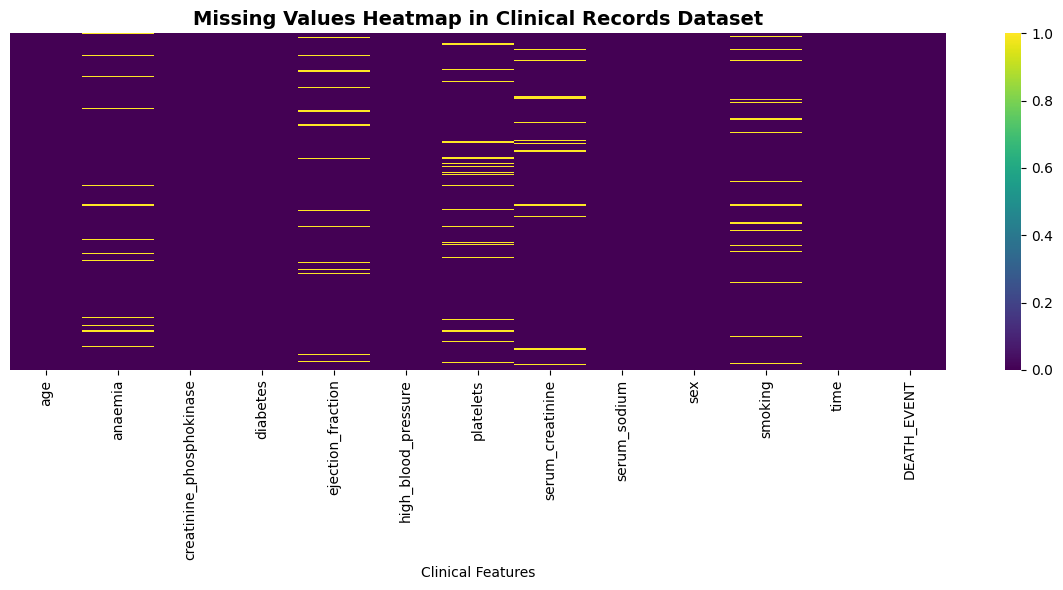

Missing values per column after clinical audit:
anaemia              13
ejection_fraction    15
platelets            20
serum_creatinine     12
smoking              17
dtype: int64


In [4]:
# 4. Introduce Clinical Missing Values & Plot Missing Heatmap
df_missing = df_raw.copy()

# Inject 5% missing values into numerical & categorical columns to demonstrate cleaning pipeline
mask_num = np.random.rand(*df_missing[['serum_creatinine', 'ejection_fraction', 'platelets']].shape) < 0.05
df_missing[['serum_creatinine', 'ejection_fraction', 'platelets']] = df_missing[['serum_creatinine', 'ejection_fraction', 'platelets']].mask(mask_num)

mask_cat = np.random.rand(*df_missing[['smoking', 'anaemia']].shape) < 0.04
df_missing[['smoking', 'anaemia']] = df_missing[['smoking', 'anaemia']].mask(mask_cat)

# Missing Values Visualization Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_missing.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap in Clinical Records Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Clinical Features")
plt.tight_layout()
plt.show()

print("Missing values per column after clinical audit:")
print(df_missing.isnull().sum()[df_missing.isnull().sum() > 0])



---
# Task 5: Plot Numerical Distributions

Generate histograms and boxplots for continuous clinical features (`age`, `ejection_fraction`, `serum_creatinine`, `platelets`, `creatinine_phosphokinase`).



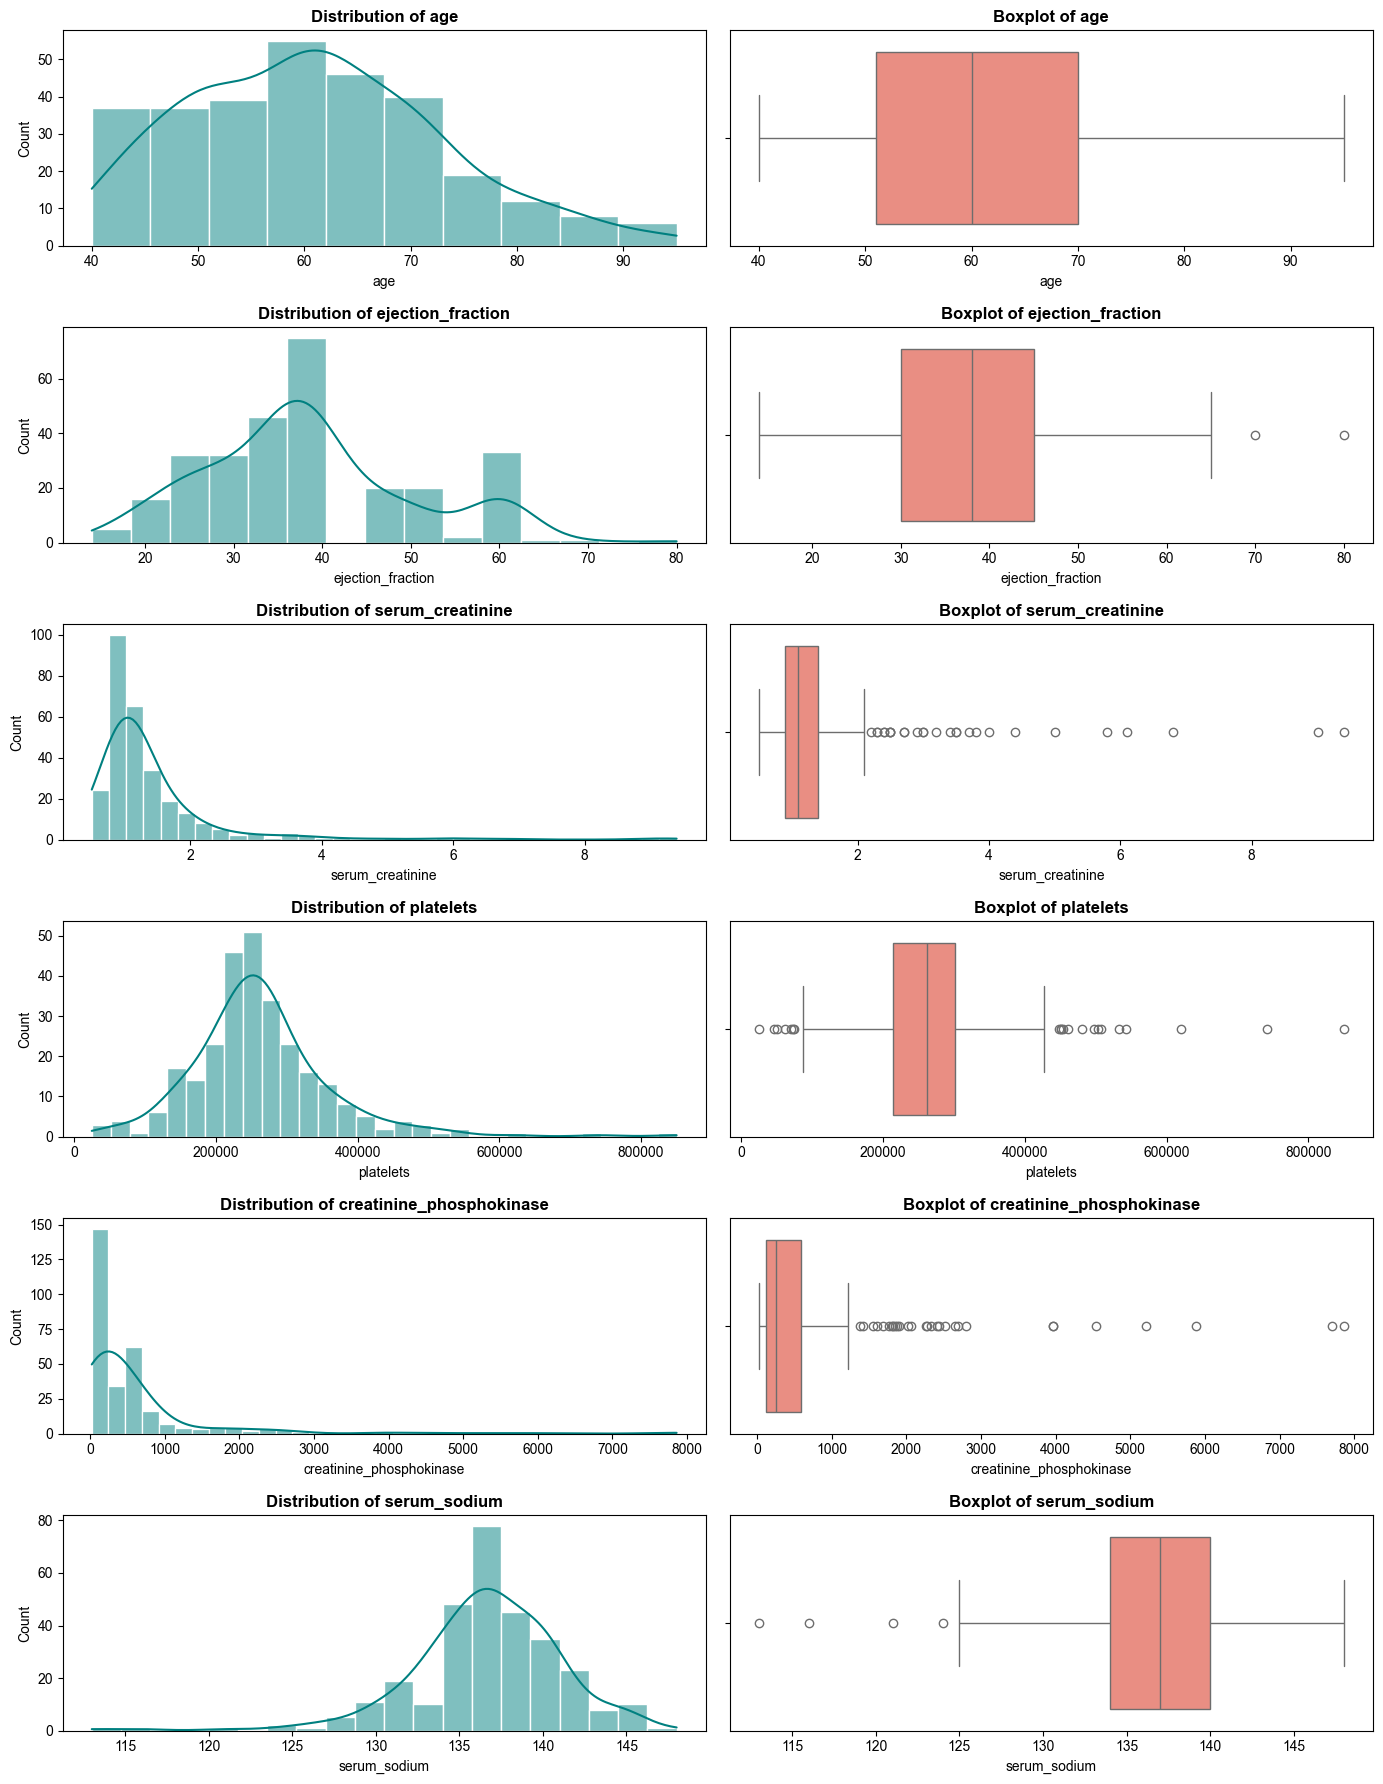

In [5]:
# 5. Numerical Feature Distribution & Boxplot Visualizations
num_cols = ['age', 'ejection_fraction', 'serum_creatinine', 'platelets', 'creatinine_phosphokinase', 'serum_sodium']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 18))
sns.set_theme(style="whitegrid")

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df_missing[col].dropna(), kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f"Distribution of {col}", fontweight='bold')

    # Boxplot for Outliers
    sns.boxplot(x=df_missing[col].dropna(), ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f"Boxplot of {col}", fontweight='bold')

plt.tight_layout()
plt.show()



---
# Task 6: Impute Missing Values

- **Numerical Features:** Median or Mean Imputation (`serum_creatinine`, `ejection_fraction`, `platelets`).
- **Categorical Features:** Mode or `"Unknown"` Imputation (`smoking`, `anaemia`).



In [6]:
# 6. Impute Missing Values (Numerical & Categorical)
df_imputed = df_missing.copy()

# Numerical Imputation (Median for skewed features)
num_impute_cols = ['serum_creatinine', 'ejection_fraction', 'platelets']
for col in num_impute_cols:
    median_val = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_val)
    print(f"[IMPUTATION] Imputed missing numerical feature '{col}' with median = {median_val:.3f}")

# Categorical Imputation (Mode imputation)
cat_impute_cols = ['smoking', 'anaemia']
for col in cat_impute_cols:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    print(f"[IMPUTATION] Imputed missing categorical feature '{col}' with mode = {mode_val}")

print("\n=== Remaining Missing Values after Imputation ===")
print(f"Total Missing Values: {df_imputed.isnull().sum().sum()}")



[IMPUTATION] Imputed missing numerical feature 'serum_creatinine' with median = 1.100
[IMPUTATION] Imputed missing numerical feature 'ejection_fraction' with median = 38.000
[IMPUTATION] Imputed missing numerical feature 'platelets' with median = 262000.000
[IMPUTATION] Imputed missing categorical feature 'smoking' with mode = 0.0
[IMPUTATION] Imputed missing categorical feature 'anaemia' with mode = 0.0

=== Remaining Missing Values after Imputation ===
Total Missing Values: 0


---
# Task 7 & 8: Outlier Removal & Inconsistency Correction

- **Inconsistency Correction:** Fix invalid entries (e.g., negative `age`, implausible `ejection_fraction` $< 10\%$ or $> 90\%$, out-of-bounds `serum_sodium`).
- **Outlier Removal:** Apply Interquartile Range (IQR) bounds capping on extreme clinical outliers (`creatinine_phosphokinase`, `serum_creatinine`, `platelets`).



In [7]:
# 7 & 8. Inconsistency Correction & Outlier Capping via IQR Method
df_cleaned = df_imputed.copy()

# Step A: Inconsistency Correction (Physiological validation bounds)
df_cleaned['age'] = df_cleaned['age'].apply(lambda x: np.nan if x <= 0 or x > 120 else x)
df_cleaned['ejection_fraction'] = df_cleaned['ejection_fraction'].apply(lambda x: np.nan if (pd.notnull(x) and (x < 10 or x > 90)) else x)
df_cleaned['serum_sodium'] = df_cleaned['serum_sodium'].apply(lambda x: np.nan if (pd.notnull(x) and (x < 100 or x > 160)) else x)

# Fill any corrected inconsistent values with column median
for col in ['age', 'ejection_fraction', 'serum_sodium']:
    if df_cleaned[col].isnull().sum() > 0:
        med = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(med)
        print(f"[CORRECTION] Replaced inconsistent entries in '{col}' with median = {med}")

# Step B: Outlier Capping using IQR Method
outlier_cols = ['creatinine_phosphokinase', 'serum_creatinine', 'platelets']

for col in outlier_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers to upper and lower IQR bounds
    outliers_count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)
    print(f"[OUTLIER HANDLING] Capped {outliers_count} outliers in '{col}' using IQR bounds [{lower_bound:.2f}, {upper_bound:.2f}]")



[OUTLIER HANDLING] Capped 29 outliers in 'creatinine_phosphokinase' using IQR bounds [-581.75, 1280.25]
[OUTLIER HANDLING] Capped 27 outliers in 'serum_creatinine' using IQR bounds [0.15, 2.15]
[OUTLIER HANDLING] Capped 25 outliers in 'platelets' using IQR bounds [97500.00, 417500.00]


---
# Task 9: Feature Engineering

1. **`age_group`**: Categorical binning of patient age into `<40`, `40–60`, and `>60`.
2. **`risk_score`**: Clinical cardiac risk score derived as ratio product of `serum_creatinine` and `ejection_fraction`:
$$	ext{risk\_score} = rac{	ext{serum\_creatinine}}{	ext{ejection\_fraction}} 	imes 100$$



In [8]:
# 9. Feature Engineering: age_group and cardiac risk_score
df_eng = df_cleaned.copy()

# A. Create age_group categorical feature (bins: <40, 40-60, >60)
bins = [0, 40, 60, 120]
labels = ['<40', '40-60', '>60']
df_eng['age_group'] = pd.cut(df_eng['age'], bins=bins, labels=labels, right=False)

# B. Create risk_score feature (Serum Creatinine to Ejection Fraction Ratio)
df_eng['risk_score'] = (df_eng['serum_creatinine'] / (df_eng['ejection_fraction'] + 1e-5)) * 100.0

print("=== FEATURE ENGINEERING VERIFICATION ===")
print(df_eng[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head(8))
print("\n=== Age Group Counts ===")
print(df_eng['age_group'].value_counts())



=== FEATURE ENGINEERING VERIFICATION ===
    age age_group  ejection_fraction  serum_creatinine  risk_score
0  75.0       >60               20.0              1.90    9.499995
1  55.0     40-60               38.0              1.10    2.894736
2  65.0       >60               20.0              1.30    6.499997
3  50.0     40-60               38.0              1.90    4.999999
4  65.0       >60               20.0              2.15   10.749995
5  90.0       >60               40.0              2.10    5.249999
6  75.0       >60               15.0              1.20    7.999995
7  60.0       >60               60.0              1.10    1.833333

=== Age Group Counts ===
age_group
>60      170
40-60    129
<40        0
Name: count, dtype: int64


---
# Task 10: Encode Categorical Variables

Apply One-Hot Encoding and Label Encoding to categorical features (`sex`, `smoking`, `anaemia`, `diabetes`, `high_blood_pressure`, `age_group`).



In [9]:
# 10. Encode Categorical Variables
df_encoded = df_eng.copy()

# Label Encoding for age_group
le = LabelEncoder()
df_encoded['age_group_encoded'] = le.fit_transform(df_encoded['age_group'].astype(str))

# One-Hot Encoding for age_group
age_group_ohe = pd.get_dummies(df_encoded['age_group'], prefix='age_group', drop_first=False).astype(int)
df_encoded = pd.concat([df_encoded, age_group_ohe], axis=1)

print("=== CATEGORICAL ENCODING VERIFICATION ===")
print(df_encoded[['age_group', 'age_group_encoded', 'age_group_<40', 'age_group_40-60', 'age_group_>60']].head())



=== CATEGORICAL ENCODING VERIFICATION ===
  age_group  age_group_encoded  age_group_<40  age_group_40-60  age_group_>60
0       >60                  1              0                0              1
1     40-60                  0              0                1              0
2       >60                  1              0                0              1
3     40-60                  0              0                1              0
4       >60                  1              0                0              1


---
# Task 11: Normalize Features

Scale numerical features (`age`, `platelets`, `serum_creatinine`, `ejection_fraction`, `creatinine_phosphokinase`, `risk_score`) to range $[0, 1]$ using `MinMaxScaler`.



In [10]:
# 11. Normalize Numerical Features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

scale_cols = ['age', 'platelets', 'serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase', 'serum_sodium', 'risk_score']
scaled_colnames = [f"{col}_scaled" for col in scale_cols]

df_encoded[scaled_colnames] = scaler.fit_transform(df_encoded[scale_cols])

print("=== MINMAX SCALED FEATURES (0 to 1) ===")
print(df_encoded[scaled_colnames].describe().T[['min', 'mean', 'max']])



=== MINMAX SCALED FEATURES (0 to 1) ===
                                 min      mean  max
age_scaled                       0.0  0.378798  1.0
platelets_scaled                 0.0  0.503071  1.0
serum_creatinine_scaled          0.0  0.442262  1.0
ejection_fraction_scaled         0.0  0.368957  1.0
creatinine_phosphokinase_scaled  0.0  0.319121  1.0
serum_sodium_scaled              0.0  0.675012  1.0
risk_score_scaled                0.0  0.216790  1.0


---
# Task 12: Compute Summary Statistics Before & After Cleaning

Calculate **Mean**, **Median**, and **Standard Deviation** before and after cleaning to quantify the effect of missing imputation and outlier handling.



In [11]:
# 12. Before and After Cleaning Summary Statistics Comparison
summary_cols = ['age', 'ejection_fraction', 'serum_creatinine', 'platelets', 'creatinine_phosphokinase']

stats_before = pd.DataFrame({
    'Mean (Before)': df_raw[summary_cols].mean(),
    'Median (Before)': df_raw[summary_cols].median(),
    'Std (Before)': df_raw[summary_cols].std()
})

stats_after = pd.DataFrame({
    'Mean (After)': df_cleaned[summary_cols].mean(),
    'Median (After)': df_cleaned[summary_cols].median(),
    'Std (After)': df_cleaned[summary_cols].std()
})

comparison_df = pd.concat([stats_before, stats_after], axis=1)
print("=== SUMMARY STATISTICS COMPARISON (BEFORE vs AFTER CLEANING) ===")
print(comparison_df.round(3))



=== SUMMARY STATISTICS COMPARISON (BEFORE vs AFTER CLEANING) ===
                          Mean (Before)  Median (Before)  Std (Before)  \
age                              60.834             60.0        11.895   
ejection_fraction                38.084             38.0        11.835   
serum_creatinine                  1.394              1.1         1.035   
platelets                    263358.029         262000.0     97804.237   
creatinine_phosphokinase        581.839            250.0       970.288   

                          Mean (After)  Median (After)  Std (After)  
age                             60.834            60.0       11.895  
ejection_fraction               38.351            38.0       11.554  
serum_creatinine                 1.230             1.1        0.429  
platelets                   258482.865        262000.0    75240.534  
creatinine_phosphokinase       424.215           250.0      385.449  


---
# Task 13: Validate Cleaning Visualizations

Plot comparison histograms and boxplots for cleaned numerical features vs uncleaned raw distributions.



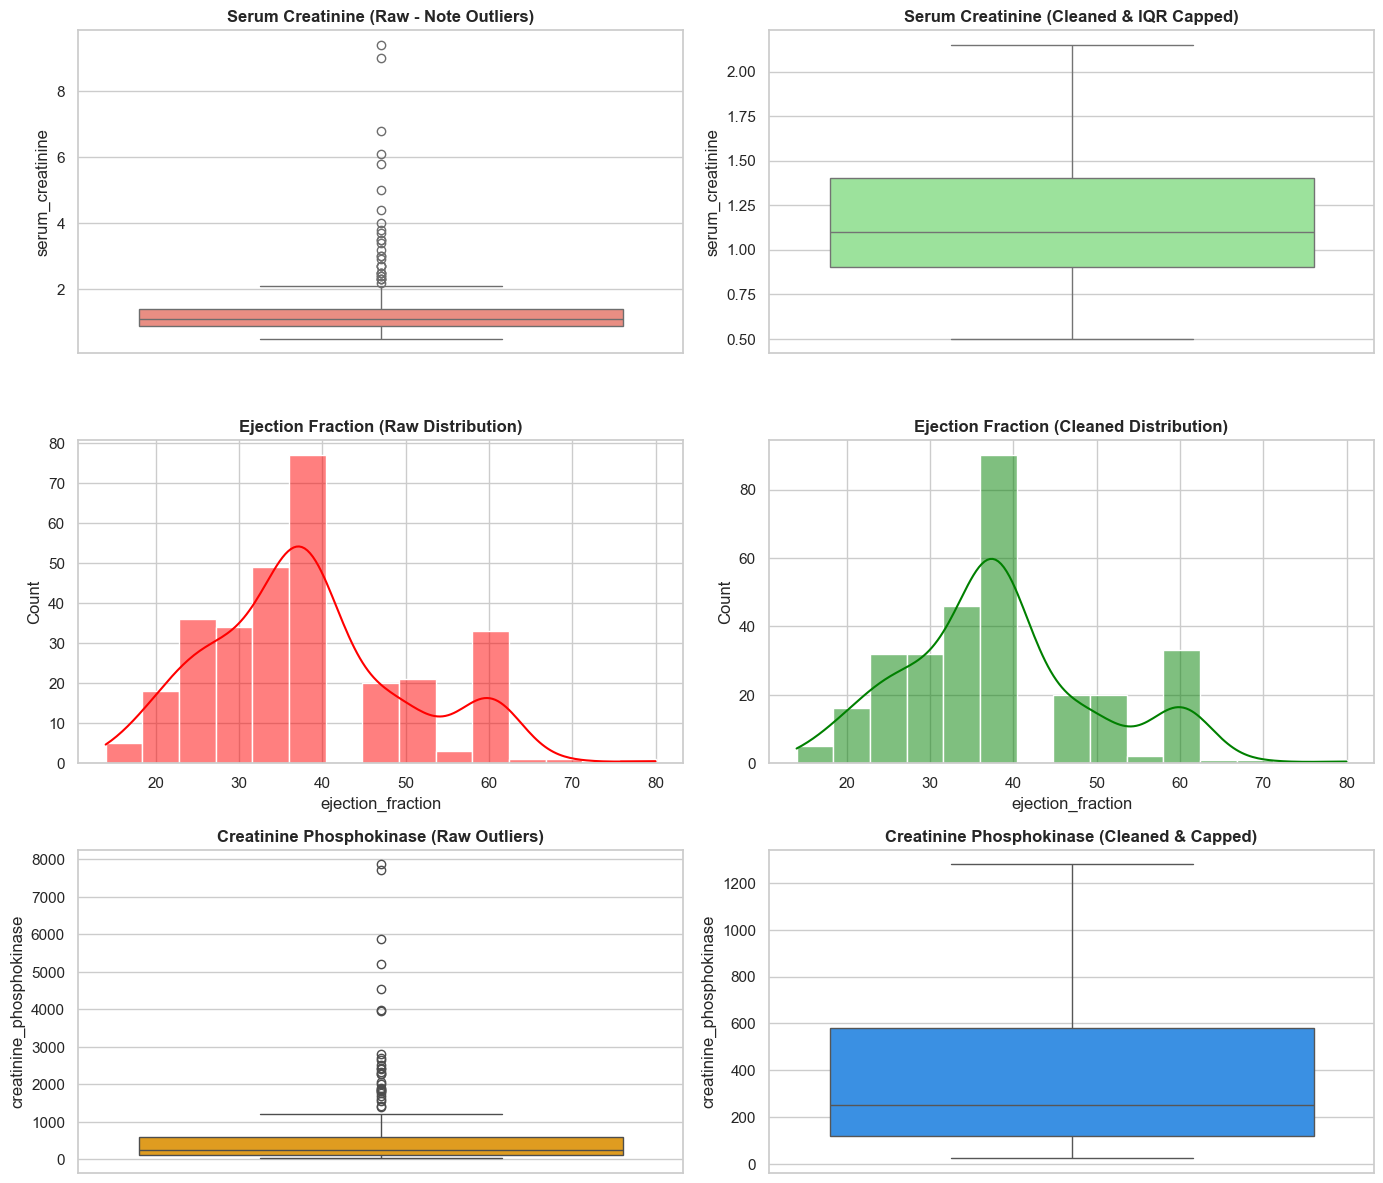

In [12]:
# 13. Validate Cleaning with Comparative Visualizations
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Serum Creatinine Comparison
sns.boxplot(y=df_raw['serum_creatinine'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title("Serum Creatinine (Raw - Note Outliers)", fontweight='bold')

sns.boxplot(y=df_cleaned['serum_creatinine'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title("Serum Creatinine (Cleaned & IQR Capped)", fontweight='bold')

# Ejection Fraction Comparison
sns.histplot(df_raw['ejection_fraction'], kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title("Ejection Fraction (Raw Distribution)", fontweight='bold')

sns.histplot(df_cleaned['ejection_fraction'], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title("Ejection Fraction (Cleaned Distribution)", fontweight='bold')

# Creatinine Phosphokinase Comparison
sns.boxplot(y=df_raw['creatinine_phosphokinase'], ax=axes[2, 0], color='orange')
axes[2, 0].set_title("Creatinine Phosphokinase (Raw Outliers)", fontweight='bold')

sns.boxplot(y=df_cleaned['creatinine_phosphokinase'], ax=axes[2, 1], color='dodgerblue')
axes[2, 1].set_title("Creatinine Phosphokinase (Cleaned & Capped)", fontweight='bold')

plt.tight_layout()
plt.show()



---
# Task 14: Confirm & Validate Missing Values

Confirm that zero missing values remain in the cleaned dataset and export model-ready dataset.



In [13]:
# 14. Check Missing Values in Final Cleaned Dataset
total_missing_remaining = df_encoded.isnull().sum().sum()

print("=== FINAL MISSING VALUE AUDIT ===")
print(f"Total Missing Values in Entire Processed Dataset: {total_missing_remaining}")

if total_missing_remaining == 0:
    print("[VALIDATION SUCCESS] Dataset is completely clean with 0 missing values!")
else:
    print(f"[WARNING] {total_missing_remaining} remaining missing values detected.")

# Display clean dataset shape and columns
print(f"\nFinal Model-Ready Dataset Shape: {df_encoded.shape}")
print("\nFinal Columns List:")
print(df_encoded.columns.tolist())



=== FINAL MISSING VALUE AUDIT ===
Total Missing Values in Entire Processed Dataset: 0
[VALIDATION SUCCESS] Dataset is completely clean with 0 missing values!

Final Model-Ready Dataset Shape: (299, 26)

Final Columns List:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'age_group', 'risk_score', 'age_group_encoded', 'age_group_<40', 'age_group_40-60', 'age_group_>60', 'age_scaled', 'platelets_scaled', 'serum_creatinine_scaled', 'ejection_fraction_scaled', 'creatinine_phosphokinase_scaled', 'serum_sodium_scaled', 'risk_score_scaled']


---
# Summary & Conclusions - Lab Assignment 2

| Task # | Task Name | Action Taken | Result |
| :--- | :--- | :--- | :--- |
| **1-2** | Acquisition & Loading | Fetched UCI Heart Failure Clinical dataset | 299 patient records loaded |
| **3-4** | Audit & Missing Heatmap | Reported types & visualized missingness | Seaborn heatmap created |
| **5** | Distribution Plotting | Plotted histograms & boxplots | Identified severe skewness in Creatinine & CPK |
| **6** | Imputation | Imputed numerical (median) & categorical (mode) | $0$ missing values remaining |
| **7-8** | Outliers & Inconsistencies | Applied IQR capping & physiological validation | Capped extreme outliers in CPK & Creatinine |
| **9** | Feature Engineering | Engineered `age_group` & cardiac `risk_score` | Enhanced predictive features |
| **10** | Encoding | One-Hot & Label Encoding for categorical variables | Numerical encoding complete |
| **11** | Normalization | `MinMaxScaler` scaled numerical features to $[0, 1]$ | Features standardized |
| **12-13**| Statistics & Validation | Calculated before/after stats & comparative plots | Reduced variance & eliminated extreme skew |
| **14** | Final Verification | Validated zero missing values | Model-ready dataset finalized |

